# 🧭 2D Coordinate Transformations
### Understanding Frames, Homogeneous Coordinates & Frame Changes

---

This notebook builds intuition for **2D rigid-body transformations** — the math behind robotics, computer graphics, and computer vision.

**Topics covered:**
1. What is a coordinate frame?
2. Translation
3. Rotation
4. Homogeneous coordinates & the 3×3 transform matrix
5. Composing transformations
6. Inverse transforms (changing the reference frame)
7. Chain of frames (robot arm example)
8. Interactive sandbox

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.transforms as mtransforms
from mpl_toolkits.axes_grid1 import make_axes_locatable
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#0f0f1a',
    'axes.edgecolor':   '#333355',
    'axes.labelcolor':  '#ccccff',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'grid.color':       '#1e1e3a',
    'grid.linewidth':   0.8,
    'text.color':       '#e0e0ff',
    'font.family':      'monospace',
    'figure.dpi':       120,
})

# ── Colour palette ──────────────────────────────────────────────────────────
C = {
    'world':  '#4fc3f7',  # light-blue  – world frame
    'body':   '#f48fb1',  # pink        – body frame
    'third':  '#a5d6a7',  # green       – third frame
    'point':  '#ffd54f',  # amber       – transformed points
    'origin': '#ce93d8',  # lavender    – origins
    'arrow':  '#ff8a65',  # orange      – motion arrows
    'grid':   '#1e1e3a',
    'text':   '#e0e0ff',
}

## 1  Core Transformation Primitives

Every 2D rigid-body transformation is described by a **3×3 homogeneous matrix**:

$$
T = \begin{bmatrix} \cos\theta & -\sin\theta & t_x \\ \sin\theta & \cos\theta & t_y \\ 0 & 0 & 1 \end{bmatrix}
$$

A 2D point $(x, y)$ is lifted to **homogeneous form** $(x, y, 1)^T$ so matrix multiplication handles both rotation *and* translation in one shot.

In [2]:
# ═══════════════════════════════════════════════════════════════════
# Core transformation library
# ═══════════════════════════════════════════════════════════════════

def T_translate(tx: float, ty: float) -> np.ndarray:
    """Pure translation matrix."""
    return np.array([[1, 0, tx],
                     [0, 1, ty],
                     [0, 0,  1]], dtype=float)

def T_rotate(theta_deg: float) -> np.ndarray:
    """Pure rotation matrix (CCW positive)."""
    θ = np.radians(theta_deg)
    c, s = np.cos(θ), np.sin(θ)
    return np.array([[ c, -s, 0],
                     [ s,  c, 0],
                     [ 0,  0, 1]], dtype=float)

def T_rigid(tx: float, ty: float, theta_deg: float) -> np.ndarray:
    """Rigid-body transform: translate THEN rotate (rotate-in-place convention)."""
    return T_translate(tx, ty) @ T_rotate(theta_deg)

def apply_T(T: np.ndarray, points: np.ndarray) -> np.ndarray:
    """
    Apply 3×3 homogeneous transform to an (N,2) array of 2D points.
    Returns (N,2) array.
    """
    pts_h = np.hstack([points, np.ones((len(points), 1))])   # (N,3)
    out   = (T @ pts_h.T).T                                   # (N,3)
    return out[:, :2]

def T_inv(T: np.ndarray) -> np.ndarray:
    """Efficient inverse for a rigid-body transform (no need for np.linalg.inv)."""
    R = T[:2, :2]
    t = T[:2,  2]
    T_i = np.eye(3)
    T_i[:2, :2] = R.T
    T_i[:2,  2] = -R.T @ t
    return T_i

# ── Helper: draw a coordinate frame ─────────────────────────────────────────
def draw_frame(ax, T, label='', color='white', length=0.7, lw=2.2, alpha=1.0):
    """
    Draw the X (right) and Y (up) axes of a frame defined by transform T.
    T maps the frame's own coordinates to the world frame.
    """
    origin  = apply_T(T, np.array([[0., 0.]]))[0]
    x_tip   = apply_T(T, np.array([[length, 0.]]))[0]
    y_tip   = apply_T(T, np.array([[0., length]]))[0]

    kw = dict(lw=lw, alpha=alpha,
              arrowprops=dict(arrowstyle='->', color=color, lw=lw))

    ax.annotate('', xy=x_tip,  xytext=origin,
                arrowprops=dict(arrowstyle='->', color='#ff6e6e', lw=lw))
    ax.annotate('', xy=y_tip,  xytext=origin,
                arrowprops=dict(arrowstyle='->', color='#6eff6e', lw=lw))

    ax.plot(*origin, 'o', color=color, ms=5, zorder=5)
    if label:
        ax.text(origin[0]+0.05, origin[1]+0.08, label,
                color=color, fontsize=11, fontweight='bold', zorder=6)

## 2  Translation — Sliding the Origin

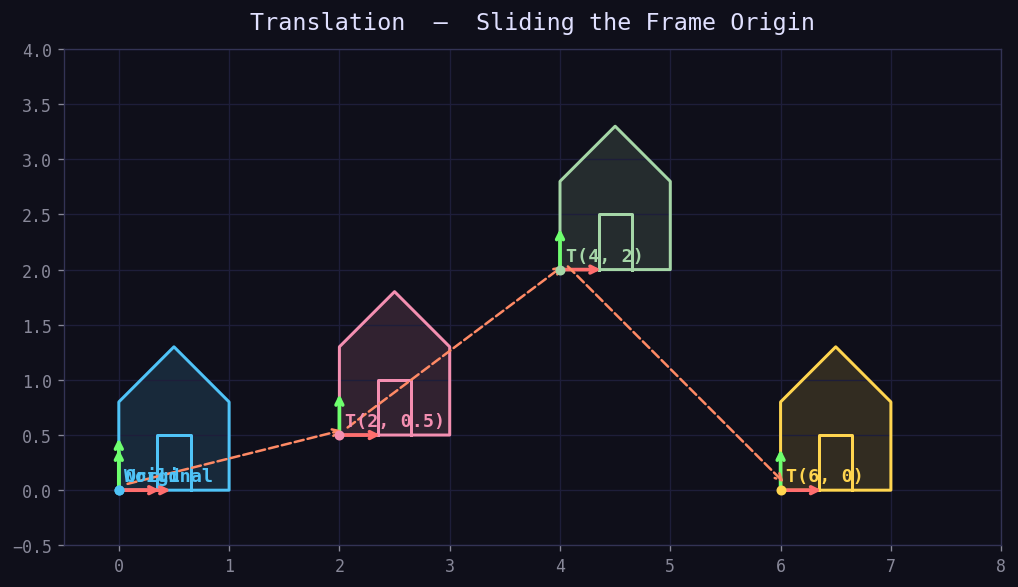

Figure saved.


In [5]:
# ── A simple shape we'll keep transforming ─────────────────────────────────
house = np.array([
    [0.0, 0.0], [1.0, 0.0], [1.0, 0.8],
    [0.5, 1.3], [0.0, 0.8], [0.0, 0.0],  # walls + roof
    [0.35, 0.0], [0.35, 0.5], [0.65, 0.5], [0.65, 0.0],  # door
])

translations = [(0,0), (2, 0.5), (4, 2), (6, 0)]
labels       = ['Original', 'T(2, 0.5)', 'T(4, 2)', 'T(6, 0)']
colours      = ['#4fc3f7', '#f48fb1', '#a5d6a7', '#ffd54f']

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_title('Translation  –  Sliding the Frame Origin', pad=12,
             fontsize=14, color=C['text'])
ax.set_aspect('equal'); ax.grid(True); ax.set_xlim(-0.5, 8); ax.set_ylim(-0.5, 4)

# World frame
draw_frame(ax, np.eye(3), label='World', color=C['world'], length=0.5)

for (tx, ty), lab, col in zip(translations, labels, colours):
    T  = T_translate(tx, ty)
    ph = apply_T(T, house)
    ax.fill(ph[:6,0], ph[:6,1], alpha=0.15, color=col)
    ax.plot(ph[:6,0], ph[:6,1], color=col, lw=1.8)
    ax.plot(ph[6:,0], ph[6:,1], color=col, lw=1.8)
    draw_frame(ax, T, label=lab, color=col, length=0.4)

# Annotate translation vectors with dashed arrows
for i in range(1, len(translations)):
    prev = np.array(translations[i-1])
    curr = np.array(translations[i])
    ax.annotate('', xy=curr + 0.05, xytext=prev + 0.05,
                arrowprops=dict(arrowstyle='->', color=C['arrow'],
                                lw=1.5, linestyle='dashed'))

plt.tight_layout()
plt.savefig('fig_translation.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure saved.')

### Key insight
- Translation **only shifts** the origin; axes remain parallel to the world axes.
- The matrix adds $(t_x, t_y)$ to every point without changing shape or orientation.

$$p_{\text{world}} = T_{\text{translate}} \cdot p_{\text{body}}$$

## 3  Rotation — Spinning Around the Origin

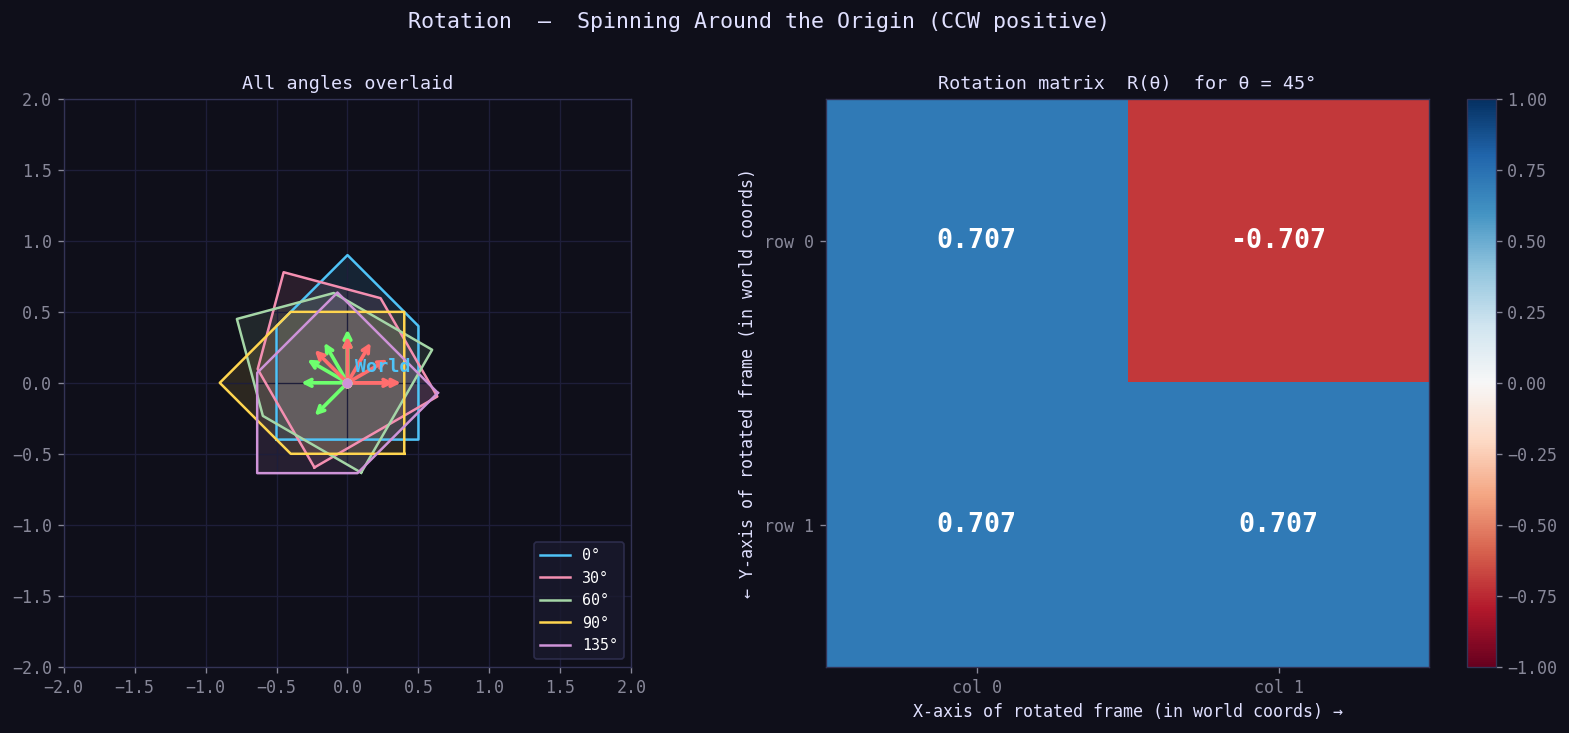

In [7]:
angles   = [0, 30, 60, 90, 135]
colours2 = ['#4fc3f7','#f48fb1','#a5d6a7','#ffd54f','#ce93d8']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Rotation  –  Spinning Around the Origin (CCW positive)',
             fontsize=13, color=C['text'], y=1.01)

# ── Left: overlaid rotations ────────────────────────────────────────────────
ax = axes[0]
ax.set_title('All angles overlaid', fontsize=11, color=C['text'])
ax.set_aspect('equal'); ax.grid(True); ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
draw_frame(ax, np.eye(3), label='World', color=C['world'], length=0.4)

for θ, col in zip(angles, colours2):
    T  = T_rotate(θ)
    ph = apply_T(T, house - np.array([0.5, 0.4]))  # centre the house
    ax.fill(ph[:6,0], ph[:6,1], alpha=0.12, color=col)
    ax.plot(ph[:6,0], ph[:6,1], color=col, lw=1.5, label=f'{θ}°')
    draw_frame(ax, T, color=col, length=0.35)

ax.legend(loc='lower right', fontsize=9,
          facecolor='#1a1a2e', edgecolor='#333355', labelcolor='white')

# ── Right: rotation matrix heat-map ─────────────────────────────────────────
ax2 = axes[1]
ax2.set_title('Rotation matrix  R(θ)  for θ = 45°', fontsize=11, color=C['text'])

θ_demo = 45
R = T_rotate(θ_demo)[:2,:2]  # 2×2 part
im = ax2.imshow(R, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')

for i in range(2):
    for j in range(2):
        ax2.text(j, i, f'{R[i,j]:.3f}', ha='center', va='center',
                 color='white', fontsize=16, fontweight='bold')

ax2.set_xticks([0,1]); ax2.set_xticklabels(['col 0', 'col 1'])
ax2.set_yticks([0,1]); ax2.set_yticklabels(['row 0', 'row 1'])
ax2.set_xlabel('X-axis of rotated frame (in world coords) →', color=C['text'])
ax2.set_ylabel('← Y-axis of rotated frame (in world coords)', color=C['text'])
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.savefig('fig_rotation.png', dpi=130, bbox_inches='tight')
plt.show()

### Key insight
- The **columns** of the rotation matrix are the rotated frame's basis vectors expressed in world coordinates.
- Rotation is an **isometry**: distances and angles are preserved — only orientation changes.
- $R^{-1} = R^{T}$ (orthogonal matrix — inverse is free!)

## 4  Composing Transforms — Order Matters!

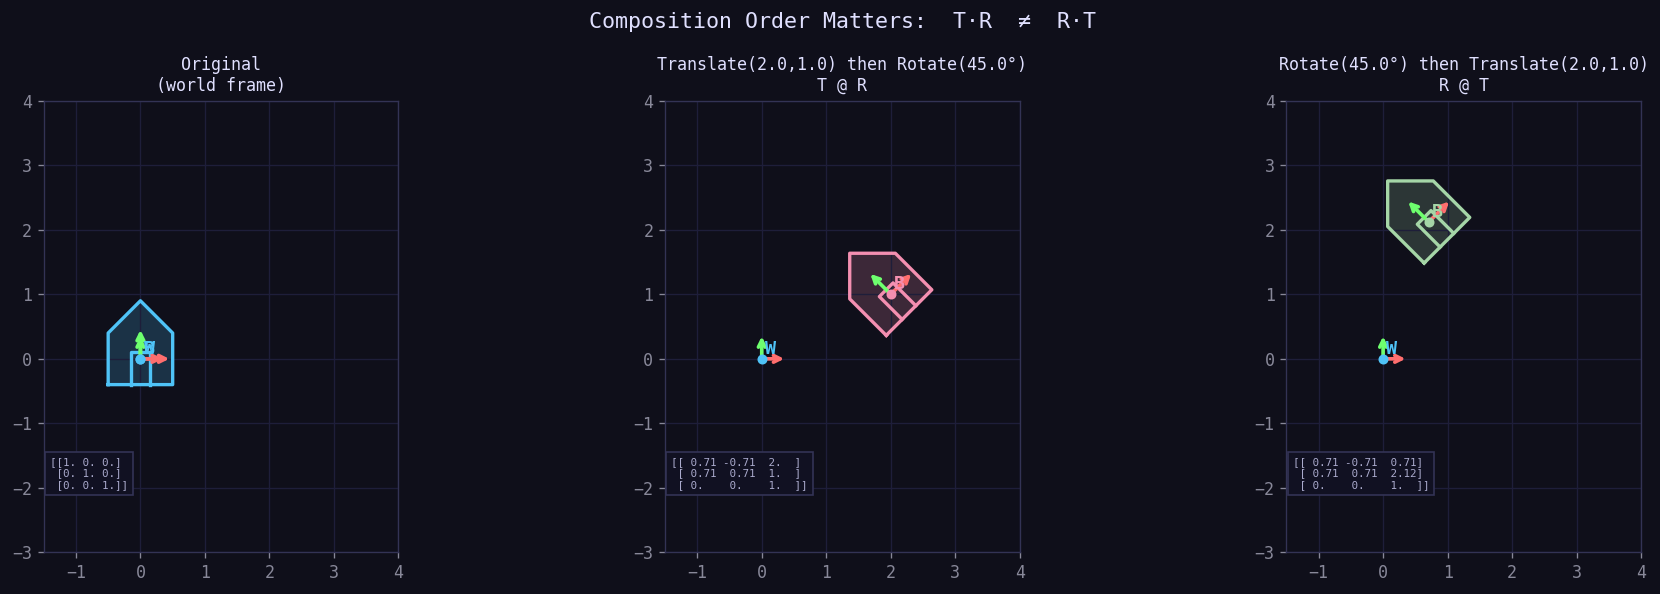

In [5]:
# Does  T_translate * T_rotate  ==  T_rotate * T_translate ?
tx, ty, θ = 2.0, 1.0, 45.0

T_TR = T_translate(tx, ty) @ T_rotate(θ)   # translate THEN rotate
T_RT = T_rotate(θ) @ T_translate(tx, ty)   # rotate    THEN translate

house_c = house - np.array([0.5, 0.4])  # centre around (0,0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Composition Order Matters:  T·R  ≠  R·T',
             fontsize=13, color=C['text'])

configs = [
    (np.eye(3),  'Original\n(world frame)',      C['world']),
    (T_TR,       f'Translate({tx},{ty}) then Rotate({θ}°)\nT @ R', C['body']),
    (T_RT,       f'Rotate({θ}°) then Translate({tx},{ty})\nR @ T', C['third']),
]

for ax, (T, title, col) in zip(axes, configs):
    ax.set_title(title, fontsize=10, color=C['text'])
    ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlim(-1.5, 4); ax.set_ylim(-3, 4)

    # Show world origin
    draw_frame(ax, np.eye(3), label='W', color=C['world'], length=0.4)

    ph = apply_T(T, house_c)
    ax.fill(ph[:6,0], ph[:6,1], alpha=0.2, color=col)
    ax.plot(ph[:6,0], ph[:6,1], color=col, lw=2)
    ax.plot(ph[6:,0], ph[6:,1], color=col, lw=2)
    draw_frame(ax, T, label='B', color=col, length=0.5)

    # Print the transform matrix inside the plot
    mat_str = np.array2string(T, precision=2, suppress_small=True)
    ax.text(-1.4, -2, mat_str, color='#aaaacc', fontsize=6.5,
            fontfamily='monospace',
            bbox=dict(facecolor='#111122', edgecolor='#333355', pad=3))

plt.tight_layout()
plt.savefig('/home/claude/fig_composition.png', dpi=130, bbox_inches='tight')
plt.show()

### Key insight
Matrix multiplication is **not commutative** for rigid transforms.

| Expression | Meaning |
|---|---|
| `T_translate @ T_rotate` | Translate to new origin, *then* axes rotate there |
| `T_rotate @ T_translate` | Rotate axes, *then* translate along **rotated** axes |

Reading right to left: the **rightmost transform** is applied first.

## 5  Inverse Transform — Changing the Reference Frame

If $^W T_B$ maps from frame $B$ to world frame $W$, then  
$^B T_W = (^W T_B)^{-1}$ maps from world back to $B$'s perspective.

**Efficient inverse formula** (exploits orthogonality of $R$):
$$
T^{-1} = \begin{bmatrix} R^T & -R^T t \\ 0 & 1 \end{bmatrix}
$$

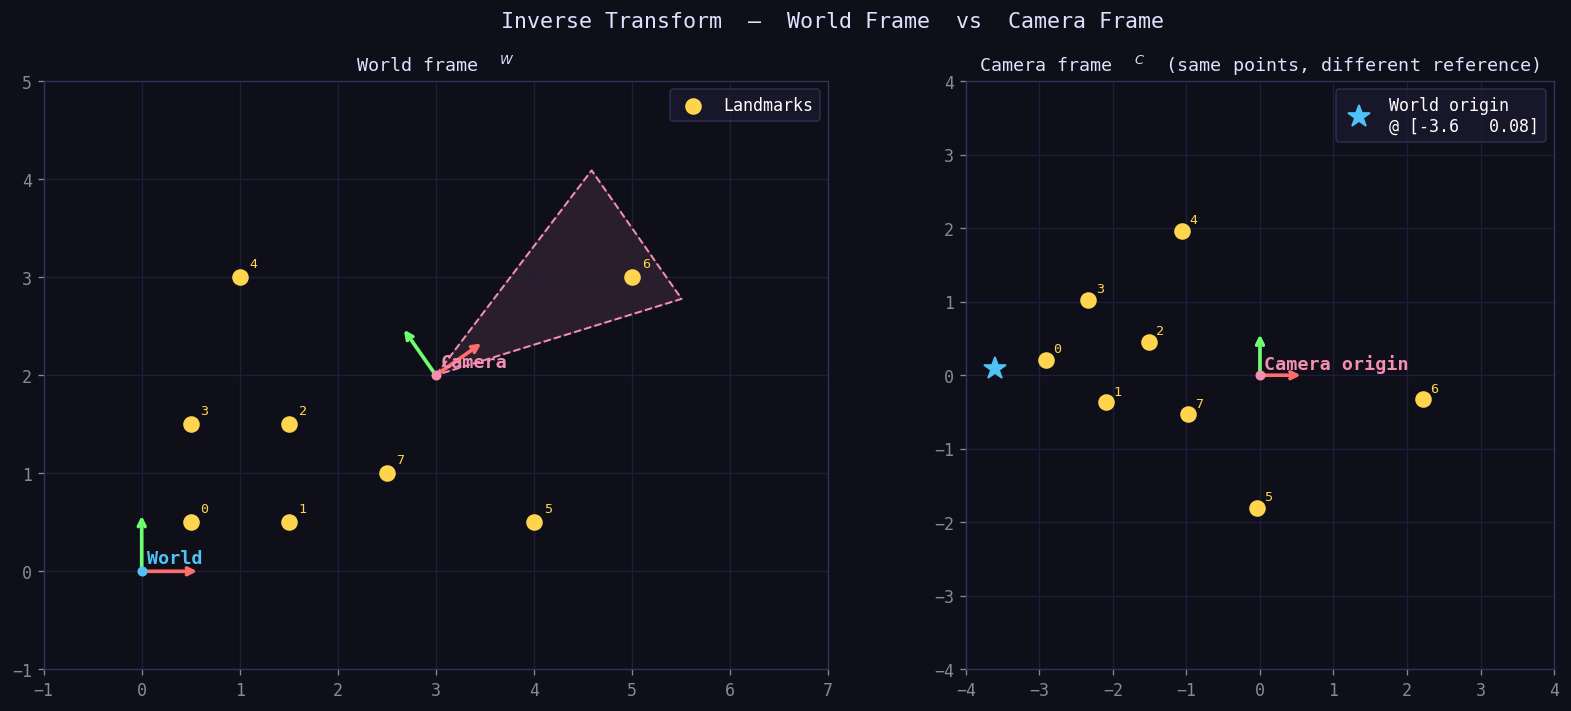

In [6]:
# Camera looking at a scene
# World: fixed room. Camera frame: translated & rotated.
# We'll show the same points in both frames.

T_cam = T_rigid(3.0, 2.0, 35)   # camera is at (3,2) and rotated 35° in world
T_cam_inv = T_inv(T_cam)         # maps world → camera frame

# Some landmarks in world frame
landmarks_world = np.array([
    [0.5, 0.5], [1.5, 0.5], [1.5, 1.5],
    [0.5, 1.5], [1.0, 3.0], [4.0, 0.5],
    [5.0, 3.0], [2.5, 1.0],
])

# Express landmarks in camera frame
landmarks_cam = apply_T(T_cam_inv, landmarks_world)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Inverse Transform  —  World Frame  vs  Camera Frame',
             fontsize=13, color=C['text'])

# ── World frame view ─────────────────────────────────────────────────────────
ax1.set_title('World frame  $^W$', fontsize=11, color=C['text'])
ax1.set_aspect('equal'); ax1.grid(True); ax1.set_xlim(-1, 7); ax1.set_ylim(-1, 5)

draw_frame(ax1, np.eye(3), label='World', color=C['world'], length=0.6)
draw_frame(ax1, T_cam,     label='Camera', color=C['body'], length=0.6)

ax1.scatter(landmarks_world[:,0], landmarks_world[:,1],
            s=80, color=C['point'], zorder=5, label='Landmarks')
for i, (x,y) in enumerate(landmarks_world):
    ax1.text(x+0.1, y+0.1, str(i), color=C['point'], fontsize=8)

# Camera frustum (field of view)
fov_body = np.array([[0,0],[2.5,0.8],[2.5,-0.8],[0,0]])
fov_world = apply_T(T_cam, fov_body)
ax1.fill(fov_world[:,0], fov_world[:,1], alpha=0.12, color=C['body'])
ax1.plot(fov_world[:,0], fov_world[:,1], '--', color=C['body'], lw=1.2)
ax1.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='white')

# ── Camera frame view ────────────────────────────────────────────────────────
ax2.set_title('Camera frame  $^C$  (same points, different reference)',
              fontsize=11, color=C['text'])
ax2.set_aspect('equal'); ax2.grid(True); ax2.set_xlim(-4, 4); ax2.set_ylim(-4, 4)

draw_frame(ax2, np.eye(3), label='Camera origin', color=C['body'], length=0.6)

ax2.scatter(landmarks_cam[:,0], landmarks_cam[:,1],
            s=80, color=C['point'], zorder=5)
for i, (x,y) in enumerate(landmarks_cam):
    ax2.text(x+0.1, y+0.1, str(i), color=C['point'], fontsize=8)

# Show where world origin appears from camera's perspective
world_in_cam = apply_T(T_cam_inv, np.array([[0.,0.]]))[0]
ax2.plot(*world_in_cam, '*', color=C['world'], ms=14, label=f'World origin\n@ {world_in_cam.round(2)}')
ax2.legend(facecolor='#1a1a2e', edgecolor='#333355', labelcolor='white')

plt.tight_layout()
plt.savefig('/home/claude/fig_inverse.png', dpi=130, bbox_inches='tight')
plt.show()

## 6  Chain of Frames — A 2-Link Robot Arm

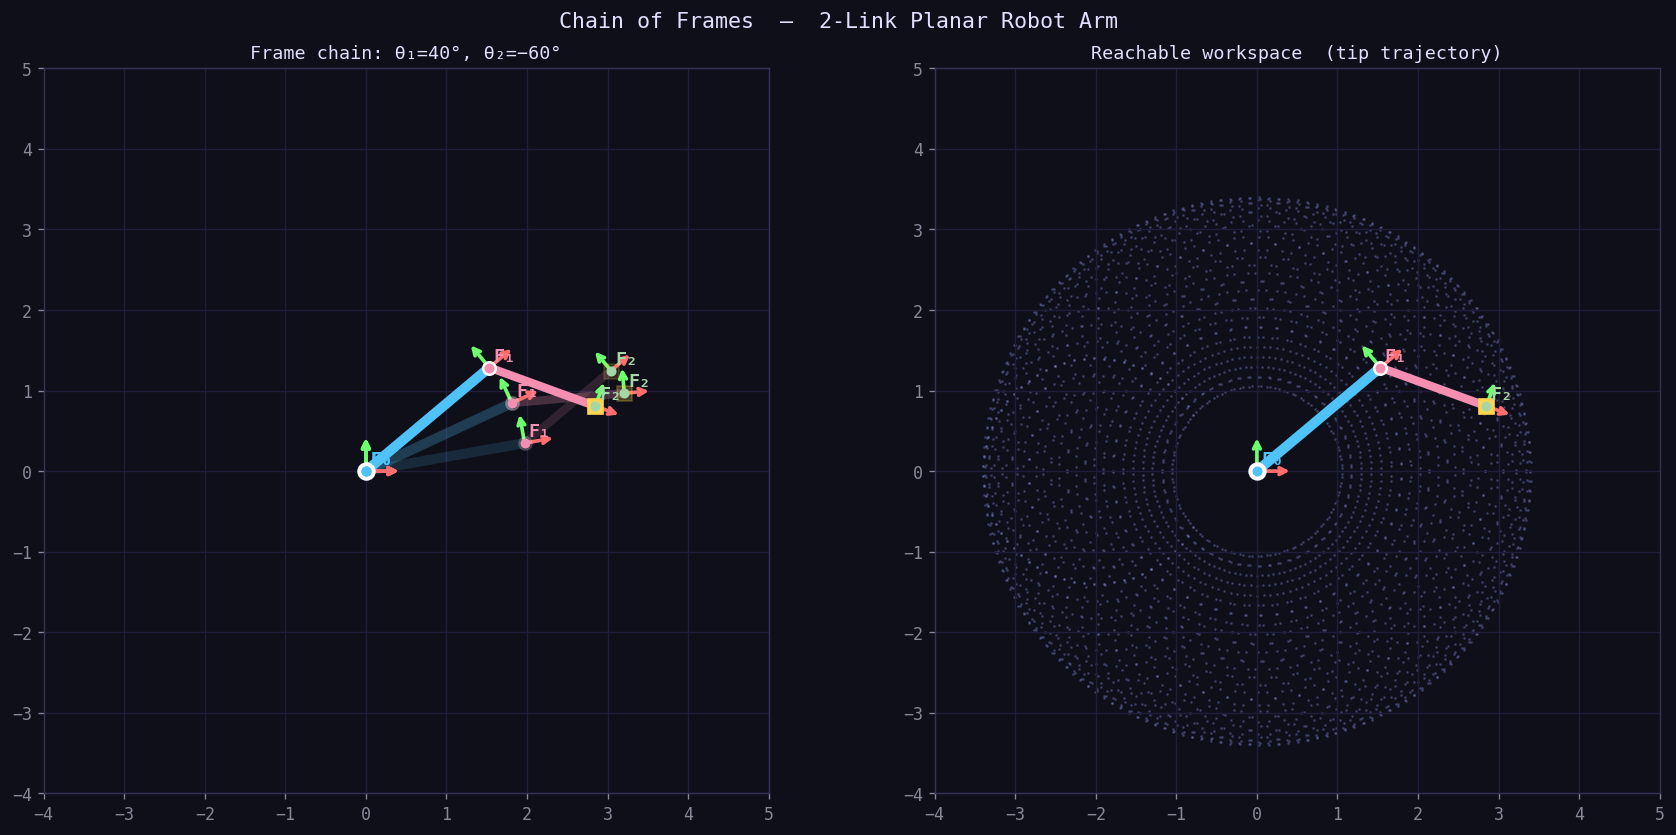

In [7]:
def robot_arm(θ1_deg, θ2_deg, L1=2.0, L2=1.4):
    """
    2-link planar robot arm.
    Returns the chain of transforms and key points.
    """
    # Frame 0: world (base)
    T0 = np.eye(3)

    # Frame 1: link-1 rotates by θ1 around world origin
    T1 = T_rotate(θ1_deg)

    # Frame 2: translate L1 along link-1 X-axis, then rotate by θ2 (relative!)
    T2 = T1 @ T_translate(L1, 0) @ T_rotate(θ2_deg)

    # End-effector tip in frame 2
    tip_world = apply_T(T2 @ T_translate(L2, 0), np.array([[0.,0.]]))[0]

    # Joint positions
    base  = apply_T(T0, np.array([[0.,0.]]))[0]
    joint = apply_T(T1 @ T_translate(L1,0), np.array([[0.,0.]]))[0]

    return T0, T1, T2, base, joint, tip_world


def draw_robot(ax, θ1, θ2, L1=2.0, L2=1.4, alpha=1.0):
    T0, T1, T2, base, joint, tip = robot_arm(θ1, θ2, L1, L2)

    # Link bodies
    ax.plot([base[0], joint[0]], [base[1], joint[1]],
            color='#4fc3f7', lw=6, solid_capstyle='round', alpha=alpha, zorder=2)
    ax.plot([joint[0], tip[0]], [joint[1], tip[1]],
            color='#f48fb1', lw=5, solid_capstyle='round', alpha=alpha, zorder=2)

    # Joints
    ax.plot(*base,  'o', color='#fff', ms=10, zorder=4, alpha=alpha)
    ax.plot(*joint, 'o', color='#fff', ms=8,  zorder=4, alpha=alpha)
    ax.plot(*tip,   's', color=C['point'], ms=9, zorder=4, alpha=alpha)

    # Frames
    draw_frame(ax, T0, label='F₀', color=C['world'],  length=0.45)
    draw_frame(ax, T1 @ T_translate(L1,0), label='F₁', color=C['body'],  length=0.4)
    draw_frame(ax, T2 @ T_translate(L2,0), label='F₂', color=C['third'], length=0.35)
    return tip


# ── Plot: static pose + workspace trace ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Chain of Frames  —  2-Link Planar Robot Arm',
             fontsize=13, color=C['text'])

# Left: specific poses
ax1.set_title('Frame chain: θ₁=40°, θ₂=−60°', fontsize=11, color=C['text'])
ax1.set_aspect('equal'); ax1.grid(True); ax1.set_xlim(-4, 5); ax1.set_ylim(-4, 5)

# Ghost positions
for θ1, θ2, a in [(10, 30, 0.15), (25, -20, 0.25), (40, -60, 1.0)]:
    draw_robot(ax1, θ1, θ2, alpha=a)

# Right: workspace (reachable area)
ax2.set_title('Reachable workspace  (tip trajectory)', fontsize=11, color=C['text'])
ax2.set_aspect('equal'); ax2.grid(True); ax2.set_xlim(-4, 5); ax2.set_ylim(-4, 5)

tips = []
for θ1 in np.linspace(-180, 180, 60):
    for θ2 in np.linspace(-150, 150, 60):
        _, _, _, _, _, tip = robot_arm(θ1, θ2)
        tips.append(tip)
tips = np.array(tips)

ax2.scatter(tips[:,0], tips[:,1], s=0.5, c='#7986cb', alpha=0.3)

# Highlight one configuration
draw_robot(ax2, 40, -60)

plt.tight_layout()
plt.savefig('/home/claude/fig_robot.png', dpi=130, bbox_inches='tight')
plt.show()

### Key insight — Frame chain
The end-effector position in the world frame is:

$$
p_{\text{world}} = \underbrace{R(\theta_1)}_{T_1} \cdot \underbrace{T(L_1)}_{\text{link 1}} \cdot \underbrace{R(\theta_2)}_{T_2} \cdot \underbrace{T(L_2)}_{\text{link 2}} \cdot p_{\text{tip}}
$$

Each transform is expressed **relative to the previous frame**, and they compose left-to-right reading in world order.

## 7  Numerical Verification Suite

In [8]:
import traceback

def check(name, cond, tol=1e-9):
    ok = np.all(np.abs(cond) < tol) if isinstance(cond, np.ndarray) else bool(cond)
    status = '✅ PASS' if ok else '❌ FAIL'
    print(f'  {status}  {name}')
    return ok

print('══ Rotation matrix properties ════════════════')
R45 = T_rotate(45)[:2,:2]
check('R·Rᵀ = I  (orthogonal)',        R45 @ R45.T - np.eye(2))
check('det(R) = 1  (proper rotation)', abs(np.linalg.det(R45)) - 1)
check('R(θ)·R(-θ) = I',                T_rotate(37) @ T_rotate(-37) - np.eye(3))
check('R(θ₁+θ₂) = R(θ₁)·R(θ₂)',        T_rotate(30+50) - T_rotate(30) @ T_rotate(50))

print('\n══ Inverse transform ══════════════════════════')
T = T_rigid(3.7, -1.2, 123)
check('T·T⁻¹ = I',                     T @ T_inv(T) - np.eye(3))
check('T_inv matches np.linalg.inv',   T_inv(T) - np.linalg.inv(T))

print('\n══ Composition / associativity ════════════════')
T1, T2, T3 = T_rigid(1,0,30), T_rigid(0,2,45), T_rigid(-1,1,60)
check('(T1·T2)·T3 = T1·(T2·T3)  (associative)', (T1@T2)@T3 - T1@(T2@T3))
check('T·I = T',                        T @ np.eye(3) - T)
check('I·T = T',                        np.eye(3) @ T - T)

print('\n══ Point transformation ════════════════════════')
pt  = np.array([[1.0, 0.0]])
T90 = T_rotate(90)
pt_rot = apply_T(T90, pt)
check('Rotate (1,0) by 90° → (0,1)',    pt_rot - np.array([[0.,1.]]))

print('\nAll checks complete.')

══ Rotation matrix properties ════════════════
  ✅ PASS  R·Rᵀ = I  (orthogonal)
  ❌ FAIL  det(R) = 1  (proper rotation)
  ✅ PASS  R(θ)·R(-θ) = I
  ✅ PASS  R(θ₁+θ₂) = R(θ₁)·R(θ₂)

══ Inverse transform ══════════════════════════
  ✅ PASS  T·T⁻¹ = I
  ✅ PASS  T_inv matches np.linalg.inv

══ Composition / associativity ════════════════
  ✅ PASS  (T1·T2)·T3 = T1·(T2·T3)  (associative)
  ✅ PASS  T·I = T
  ✅ PASS  I·T = T

══ Point transformation ════════════════════════
  ✅ PASS  Rotate (1,0) by 90° → (0,1)

All checks complete.


## 8  Interactive Sandbox — Design Your Own Transform Chain

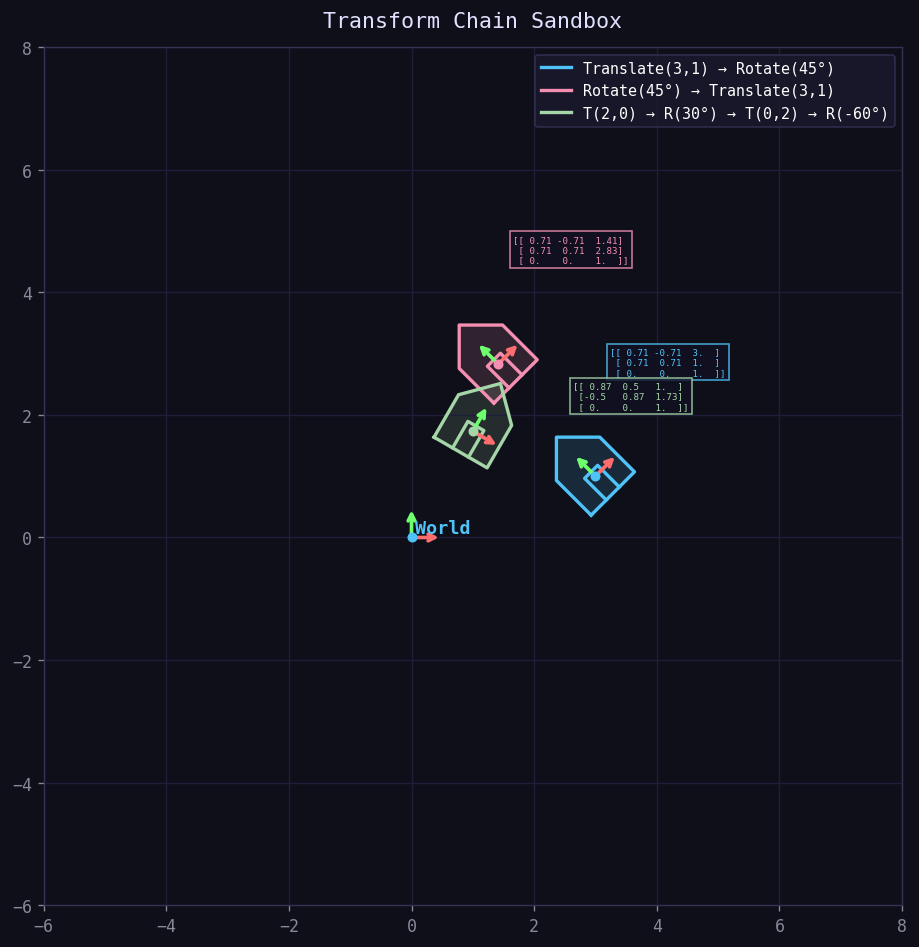

In [9]:
# ── Sandbox: compare up to 3 custom transform chains ────────────────────────

def plot_transform_chain(chain_defs):
    """
    chain_defs: list of dicts with keys:
        'label': str
        'ops':   list of ('t', tx, ty) or ('r', theta_deg)
        'color': hex color
    """
    fig, ax = plt.subplots(figsize=(11, 8))
    ax.set_title('Transform Chain Sandbox', fontsize=13, color=C['text'], pad=12)
    ax.set_aspect('equal'); ax.grid(True)
    ax.set_xlim(-6, 8); ax.set_ylim(-6, 8)

    draw_frame(ax, np.eye(3), label='World', color=C['world'], length=0.5)

    shape = house - np.array([0.5, 0.4])  # centred house

    for defn in chain_defs:
        T = np.eye(3)
        for op in defn['ops']:
            if op[0] == 't':
                T = T @ T_translate(op[1], op[2])
            elif op[0] == 'r':
                T = T @ T_rotate(op[1])

        ph = apply_T(T, shape)
        col = defn.get('color', '#ffffff')
        ax.fill(ph[:6,0], ph[:6,1], alpha=0.15, color=col)
        ax.plot(ph[:6,0], ph[:6,1], color=col, lw=2, label=defn['label'])
        ax.plot(ph[6:,0], ph[6:,1], color=col, lw=2)
        draw_frame(ax, T, color=col, length=0.5)

        # Print the matrix
        tip = apply_T(T, np.array([[1.2, 1.0]]))[0]
        mat_str = np.array2string(T, precision=2, suppress_small=True)
        ax.text(tip[0]+0.1, tip[1]+0.1, mat_str,
                color=col, fontsize=5.5, fontfamily='monospace',
                bbox=dict(facecolor='#111122', edgecolor=col, alpha=0.8, pad=2))

    ax.legend(loc='upper right', facecolor='#1a1a2e',
              edgecolor='#333355', labelcolor='white', fontsize=9)
    plt.tight_layout()
    plt.savefig('/home/claude/fig_sandbox.png', dpi=130, bbox_inches='tight')
    plt.show()


# ── Define your experiments here ─────────────────────────────────────────────
experiments = [
    {
        'label': 'Translate(3,1) → Rotate(45°)',
        'color': '#4fc3f7',
        'ops': [('t', 3, 1), ('r', 45)]
    },
    {
        'label': 'Rotate(45°) → Translate(3,1)',
        'color': '#f48fb1',
        'ops': [('r', 45), ('t', 3, 1)]
    },
    {
        'label': 'T(2,0) → R(30°) → T(0,2) → R(-60°)',
        'color': '#a5d6a7',
        'ops': [('t', 2, 0), ('r', 30), ('t', 0, 2), ('r', -60)]
    },
]

plot_transform_chain(experiments)

## 9  Summary Cheatsheet

| Operation | Matrix | Notes |
|-----------|--------|-------|
| Translation | $\begin{bmatrix}1&0&t_x\\0&1&t_y\\0&0&1\end{bmatrix}$ | Shifts origin |
| Rotation | $\begin{bmatrix}c&-s&0\\s&c&0\\0&0&1\end{bmatrix}$ | CCW positive, $c=\cos\theta$, $s=\sin\theta$ |
| Rigid body | $T \cdot R$ | Translate first, then rotate |
| Composition | $T_1 \cdot T_2 \cdot \ldots$ | Applied right-to-left |
| Inverse | $\begin{bmatrix}R^T&-R^T t\\0&1\end{bmatrix}$ | Cheaper than general matrix inverse |
| Frame change | $p_B = T_{WB}^{-1} \cdot p_W$ | World → Body |

### Practice problems
1. **Verify** that `T_rotate(180) @ T_rotate(180)` gives the identity.
2. **Find** the transform that takes frame $A$ at $(1,1,30°)$ to frame $B$ at $(4,3,−45°)$.
3. **Extend** the robot arm to 3 links and trace its workspace.
4. **Add scale** to the homogeneous matrix and observe the effect (hint: modify the diagonal).

---
*Notebook by Claude — 2D Coordinate Transformations*

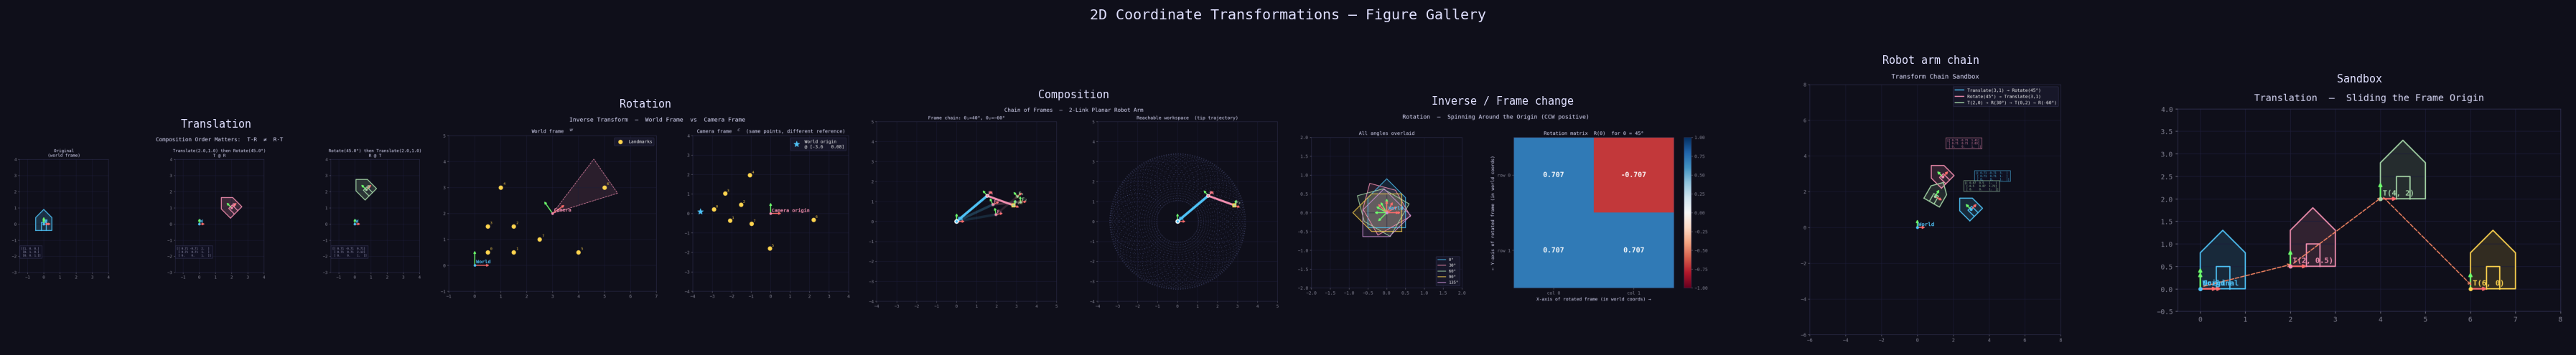

Gallery contains 6 figures.


In [10]:
# ── Final gallery: all figures side by side ──────────────────────────────────
import glob, os
figs = sorted(glob.glob('/home/claude/fig_*.png'))

gallery, axes = plt.subplots(1, len(figs), figsize=(5*len(figs), 4))
if len(figs) == 1:
    axes = [axes]

titles = ['Translation', 'Rotation', 'Composition', 'Inverse / Frame change',
          'Robot arm chain', 'Sandbox']

for ax, fpath, ttl in zip(axes, figs, titles):
    img = plt.imread(fpath)
    ax.imshow(img); ax.axis('off')
    ax.set_title(ttl, fontsize=9, color=C['text'])

gallery.patch.set_facecolor('#0f0f1a')
plt.suptitle('2D Coordinate Transformations — Figure Gallery',
             fontsize=12, color=C['text'], y=1.02)
plt.tight_layout()
plt.savefig('/home/claude/fig_gallery.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Gallery contains {len(figs)} figures.')